# Chapter 4: Data Structures and Data Types

In [1]:
import polars as pl
pl.__version__  # The book is built with Polars version 1.20.0

'1.33.0'

## Series, DataFrames, and LazyFrames

In [2]:
sales_series = pl.Series("sales", [150.00, 300.00, 250.00])

sales_series

sales
f64
150.0
300.0
250.0


In [3]:
sales_df = pl.DataFrame(
    {
        "sales": sales_series,
        "customer_id": [24, 25, 26],
    }
)

sales_df

sales,customer_id
f64,i64
150.0,24
300.0,25
250.0,26


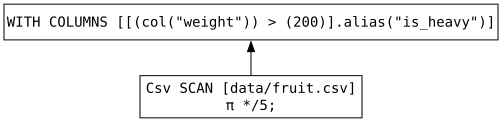

In [4]:
lazy_df = pl.scan_csv("data/fruit.csv").with_columns(
    is_heavy=pl.col("weight") > 200
)

lazy_df.show_graph()

## Data Types

### Nested Data Types

In [5]:
coordinates = pl.DataFrame(
    [
        pl.Series("point_2d", [[1, 3], [2, 5]]),
        pl.Series("point_3d", [[1, 7, 3], [8, 1, 0]]),
    ],
    schema={
        "point_2d": pl.Array(shape=2, inner=pl.Int64),
        "point_3d": pl.Array(shape=3, inner=pl.Int64),
    },
)

coordinates

point_2d,point_3d
"array[i64, 2]","array[i64, 3]"
"[1, 3]","[1, 7, 3]"
"[2, 5]","[8, 1, 0]"


In [6]:
weather_readings = pl.DataFrame(
    {
        "temperature": [[72.5, 75.0, 77.3], [68.0, 70.2]],
        "wind_speed": [[15, 20], [10, 12, 14, 16]],
    }
)

weather_readings

temperature,wind_speed
list[f64],list[i64]
"[72.5, 75.0, 77.3]","[15, 20]"
"[68.0, 70.2]","[10, 12, … 16]"


In [7]:
rating_series = pl.Series(
    "ratings",
    [
        {"Movie": "Cars", "Theatre": "NE", "Avg_Rating": 4.5},
        {"Movie": "Toy Story", "Theatre": "ME", "Avg_Rating": 4.9},
    ],
)
rating_series

ratings
struct[3]
"{""Cars"",""NE"",4.5}"
"{""Toy Story"",""ME"",4.9}"


### Missing Values

In [8]:
missing_df = pl.DataFrame(
    {
        "value": [None, 2, 3, 4, None, None, 7, 8, 9, None],
    },
)
missing_df

value
i64
null
2
3
4
null
null
7
8
9


In [9]:
missing_df.with_columns(filled_with_single=pl.col("value").fill_null(-1))

value,filled_with_single
i64,i64
null,-1
2,2
3,3
4,4
null,-1
null,-1
7,7
8,8
9,9


In [10]:
missing_df.with_columns(
    forward=pl.col("value").fill_null(strategy="forward"),
    backward=pl.col("value").fill_null(strategy="backward"),
    min=pl.col("value").fill_null(strategy="min"),
    max=pl.col("value").fill_null(strategy="max"),
    mean=pl.col("value").fill_null(strategy="mean"),
    zero=pl.col("value").fill_null(strategy="zero"),
    one=pl.col("value").fill_null(strategy="one"),
)

value,forward,backward,min,max,mean,zero,one
i64,i64,i64,i64,i64,i64,i64,i64
null,null,2,2,9,5,0,1
2,2,2,2,2,2,2,2
3,3,3,3,3,3,3,3
4,4,4,4,4,4,4,4
null,4,7,2,9,5,0,1
null,4,7,2,9,5,0,1
7,7,7,7,7,7,7,7
8,8,8,8,8,8,8,8
9,9,9,9,9,9,9,9


In [11]:
missing_df.with_columns(
    expression_mean=pl.col("value").fill_null(pl.col("value").mean())
)

value,expression_mean
i64,f64
null,5.5
2,2.0
3,3.0
4,4.0
null,5.5
null,5.5
7,7.0
8,8.0
9,9.0


In [12]:
missing_df.interpolate()

value
f64
null
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0


## Data Type Conversion

In [13]:
string_df = pl.DataFrame({"id": ["10000", "20000", "30000"]})
print(string_df)
print(f"Estimated size: {string_df.estimated_size('b')} bytes")

shape: (3, 1)
┌───────┐
│ id    │
│ ---   │
│ str   │
╞═══════╡
│ 10000 │
│ 20000 │
│ 30000 │
└───────┘
Estimated size: 15 bytes


In [14]:
int_df = string_df.select(pl.col("id").cast(pl.UInt16))
print(int_df)
print(f"Estimated size: {int_df.estimated_size('b')} bytes")

shape: (3, 1)
┌───────┐
│ id    │
│ ---   │
│ u16   │
╞═══════╡
│ 10000 │
│ 20000 │
│ 30000 │
└───────┘
Estimated size: 6 bytes


In [15]:
data_types_df = pl.DataFrame(
    {
        "id": [10000, 20000, 30000],
        "value": [1.0, 2.0, 3.0],
        "value2": ["1", "2", "3"],
    }
)

data_types_df.cast(pl.UInt16)

id,value,value2
u16,u16,u16
10000,1,1
20000,2,2
30000,3,3


In [16]:
data_types_df.cast({"id": pl.UInt16, "value": pl.Float32, "value2": pl.UInt8})

id,value,value2
u16,f32,u8
10000,1.0,1
20000,2.0,2
30000,3.0,3


In [17]:
data_types_df.cast({pl.Float64: pl.Float32, pl.String: pl.UInt8})

id,value,value2
i64,f32,u8
10000,1.0,1
20000,2.0,2
30000,3.0,3


In [18]:
import polars.selectors as cs

data_types_df.cast({cs.numeric(): pl.UInt16})

id,value,value2
u16,u16,str
10000,1,"""1"""
20000,2,"""2"""
30000,3,"""3"""


In [19]:
data_types_df

id,value,value2
i64,f64,str
10000,1.0,"""1"""
20000,2.0,"""2"""
30000,3.0,"""3"""


## Takeaways